Цель: сравнить три алгоритма построения рекомендательных систем (KNN, SVD, SVD++) на выбранном датасете (индивидуально).

Ход работы:

1. Поиск и загрузка дата – 5б
2. Анализ датасета и его преобразование – 10б
3. Выбор и обоснование метрик обучения моделей – 10б
4. Построение модели на основе KNN – 15б
5. Построение модели на основе SVD – 15б
6. Построение модели на основе SVD++ – 15б
7. Сравнительный анализ моделей – 10б
8. Выводы – 5б
9. Вопросы к защите – 15б

* Рекомендательные системы: общие принципы построения
* Статистические методы обработки данных
* Математические аспекты KNN, SVD, SVD++

## Импорты


In [1]:
!pip install -q surprise

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 1.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
!pip install -q faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.7/30.7 MB 49.9 MB/s eta 0:00:00


In [6]:
import faiss

from surprise import Dataset, Reader, KNNBasic, KNNWithMeans, KNNWithZScore, SVD, SVDpp, NMF, CoClustering
from surprise.model_selection import cross_validate, GridSearchCV
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from IPython.display import clear_output

from sentence_transformers import SentenceTransformer

import os
import random
import zipfile
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Загрузка датасета Movielens Case Dataset.

In [7]:
from google.colab import drive

drive.mount('/content/drive')

os.chdir('/content/drive/My Drive/РекомСистем/Movielens')

Mounted at /content/drive


In [8]:
movies = pd.read_csv('movies.csv', sep='::', names=['MovieID', 'Title', 'Genres'],encoding='latin1', engine='python', header=None)
print(f'Строк в датасете {len(movies):,}')

Строк в датасете 3,883


In [9]:
ratings = pd.read_csv("ratings.csv", sep="::", names=['UserID', 'MovieID', 'Rating', 'Timestamp'], encoding='latin1', engine='python', header=None)
print(f'Строк в датасете {len(ratings):,}')

Строк в датасете 1,000,209


In [10]:
users = pd.read_csv("users.csv", sep="::", names=['UserID', 'Gender', 'Age', 'Occupation', 'Zip-code'] ,encoding='latin1', engine='python', header=None)
print(f'Строк в датасете {len(users):,}')

Строк в датасете 6,040


In [11]:
movies.head()

,MovieID,Title,Genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


In [12]:
ratings.head()

,UserID,MovieID,Rating,Timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [13]:
users.head()

,UserID,Gender,Age,Occupation,Zip-code
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455


Соединим все в одну таблицу

In [14]:
# 1. Объединение ratings и movies по MovieID
ratings_movies = pd.merge(ratings, movies, on='MovieID', how='inner')
ratings_movies.shape


(1000209, 6)

In [15]:
# 2. Объединение получившейся таблицы с users по UserID
df = pd.merge(ratings_movies, users, on='UserID', how='inner')

In [16]:
desired_order = [
    'MovieID',
    'Title',
    'Genres',
    'Timestamp',
    'Rating',
    'UserID',
    'Gender',
    'Age',
    'Occupation',
    'Zip-code']

df = df[desired_order]
df.head()

,MovieID,Title,Genres,Timestamp,Rating,UserID,Gender,Age,Occupation,Zip-code
0,1193,One Flew Over the Cuckoo's Nest (1975),Drama,978300760,5,1,F,1,10,48067
1,661,James and the Giant Peach (1996),Animation|Children's|Musical,978302109,3,1,F,1,10,48067
2,914,My Fair Lady (1964),Musical|Romance,978301968,3,1,F,1,10,48067
3,3408,Erin Brockovich (2000),Drama,978300275,4,1,F,1,10,48067
4,2355,"Bug's Life, A (1998)",Animation|Children's|Comedy,978824291,5,1,F,1,10,48067


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000209 entries, 0 to 1000208
Data columns (total 10 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   MovieID     1000209 non-null  int64 
 1   Title       1000209 non-null  object
 2   Genres      1000209 non-null  object
 3   Timestamp   1000209 non-null  int64 
 4   Rating      1000209 non-null  int64 
 5   UserID      1000209 non-null  int64 
 6   Gender      1000209 non-null  object
 7   Age         1000209 non-null  int64 
 8   Occupation  1000209 non-null  int64 
 9   Zip-code    1000209 non-null  object
dtypes: int64(6), object(4)
memory usage: 76.3+ MB


## Предобработка и Анализ датасета.

In [18]:
df.columns


Index(['MovieID', 'Title', 'Genres', 'Timestamp', 'Rating', 'UserID', 'Gender',
       'Age', 'Occupation', 'Zip-code'],
      dtype='object')

In [19]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
print(df['Occupation'].value_counts())

Occupation
4     131032
0     130499
7     105425
1      85351
17     72816
20     60397
12     57214
2      50068
14     49109
16     46021
6      37205
3      31623
10     23290
15     22951
5      21850
11     20563
19     14904
13     13754
18     12086
9      11345
8       2706
Name: count, dtype: int64


In [20]:
df.isna().sum()

,0
MovieID,0
Title,0
Genres,0
Timestamp,0
Rating,0
UserID,0
Gender,0
Age,0
Occupation,0
Zip-code,0


In [21]:
df.duplicated().sum()

0

In [22]:
df.head()

,MovieID,Title,Genres,Timestamp,Rating,UserID,Gender,Age,Occupation,Zip-code
0,1193,One Flew Over the Cuckoo's Nest (1975),Drama,1970-01-01 00:00:00.978300760,5,1,F,1,10,48067
1,661,James and the Giant Peach (1996),Animation|Children's|Musical,1970-01-01 00:00:00.978302109,3,1,F,1,10,48067
2,914,My Fair Lady (1964),Musical|Romance,1970-01-01 00:00:00.978301968,3,1,F,1,10,48067
3,3408,Erin Brockovich (2000),Drama,1970-01-01 00:00:00.978300275,4,1,F,1,10,48067
4,2355,"Bug's Life, A (1998)",Animation|Children's|Comedy,1970-01-01 00:00:00.978824291,5,1,F,1,10,48067


## Выбор метрик обучения моделей

In [23]:
df_sub = df[['UserID', 'MovieID', 'Rating']]
df_sub.head()

,UserID,MovieID,Rating
0,1,1193,5
1,1,661,3
2,1,914,3
3,1,3408,4
4,1,2355,5


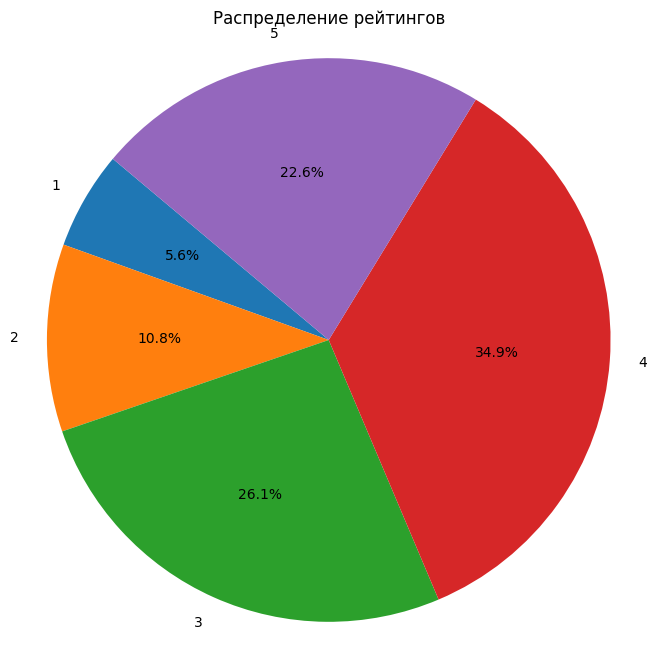

In [24]:
rating_counts = df_sub['Rating'].value_counts().sort_index()

plt.figure(figsize=(8, 8))
plt.pie(rating_counts, labels=rating_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Распределение рейтингов')
plt.axis('equal')
plt.show()

In [25]:
train_ratings, test_ratings = train_test_split(df_sub, test_size=0.2, shuffle=True, random_state=42)

In [26]:
reader = Reader(rating_scale=(1, 5))
train_data = Dataset.load_from_df(train_ratings[['UserID', 'MovieID', 'Rating']], reader)

## Построение модели на основе KNN

In [27]:
# Создаем trainset для Surprise
trainset = train_data.build_full_trainset()

In [28]:
knn = KNNBasic(sim_options={'user_based': True})
knn.fit(trainset)

print("KNN model trained.")


Computing the msd similarity matrix...
Done computing similarity matrix.
KNN model trained.


In [29]:
cross_validation_results = cross_validate(knn, train_data, measures=['RMSE', 'MAE'], cv=5, verbose=True)

print("\nCross-validation Results:")
print(f"Mean RMSE: {np.mean(cross_validation_results['test_rmse']):.4f}")
print(f"Mean MAE: {np.mean(cross_validation_results['test_mae']):.4f}")

Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Evaluating RMSE, MAE of algorithm KNNBasic on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.9342  0.9307  0.9330  0.9330  0.9306  0.9323  0.0014  
MAE (testset)     0.7367  0.7345  0.7358  0.7358  0.7346  0.7355  0.0009  
Fit time          20.15   20.92   21.31   21.45   21.41   21.05   0.49    
Test time         58.22   58.44   58.98   59.52   59.20   58.87   0.48    

Cross-validation Results:
Mean RMSE: 0.9323
Mean MAE: 0.7355


In [30]:
predictions = []
for index, row in test_ratings.iterrows():
    user_id = row['UserID']
    movie_id = row['MovieID']
    actual_rating = row['Rating']
    predicted_rating = knn.predict(user_id, movie_id).est
    predictions.append((actual_rating, predicted_rating))

# 6. Вычисление RMSE и MAE на тестовых данных
def calculate_rmse(predictions):
    return np.sqrt(np.mean([(actual - predicted)**2 for (actual, predicted) in predictions]))

def calculate_mae(predictions):
    return np.mean([abs(actual - predicted) for (actual, predicted) in predictions])

In [31]:
rmse = calculate_rmse(predictions)
mae = calculate_mae(predictions)

print("\nTest Data Results:")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")


Test Data Results:
RMSE: 0.9353
MAE: 0.7387


## Построение модели на основе SVD

In [32]:
svd = SVD()
svd.fit(trainset)

print("SVD model trained.")

SVD model trained.


In [33]:
cross_validation_results = cross_validate(svd, train_data, measures=['RMSE', 'MAE'], cv=5, verbose=True)

print("\nCross-validation Results:")
print(f"Mean RMSE: {np.mean(cross_validation_results['test_rmse']):.4f}")
print(f"Mean MAE: {np.mean(cross_validation_results['test_mae']):.4f}")

Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8871  0.8881  0.8882  0.8850  0.8904  0.8878  0.0018  
MAE (testset)     0.6971  0.6987  0.6983  0.6960  0.6996  0.6979  0.0013  
Fit time          10.21   10.45   10.51   10.43   10.44   10.41   0.10    
Test time         1.44    1.39    1.40    1.40    1.39    1.41    0.02    

Cross-validation Results:
Mean RMSE: 0.8878
Mean MAE: 0.6979


In [34]:
predictions = []
for index, row in test_ratings.iterrows():
    user_id = row['UserID']
    movie_id = row['MovieID']
    actual_rating = row['Rating']
    predicted_rating = svd.predict(user_id, movie_id).est
    predictions.append((actual_rating, predicted_rating))

def calculate_rmse(predictions):
    return np.sqrt(np.mean([(actual - predicted)**2 for (actual, predicted) in predictions]))

def calculate_mae(predictions):
    return np.mean([abs(actual - predicted) for (actual, predicted) in predictions])

In [35]:
rmse = calculate_rmse(predictions)
mae = calculate_mae(predictions)

print("\nTest Data Results:")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")


Test Data Results:
RMSE: 0.8918
MAE: 0.7018


## Построение модели на основе SVD++

In [36]:
svdpp = SVDpp()
svdpp.fit(trainset)

print("SVD++ model trained.")

SVD++ model trained.


In [37]:
cross_validation_results = cross_validate(svdpp, train_data, measures=['RMSE', 'MAE'], cv=5, verbose=True)

print("\nCross-validation Results:")
print(f"Mean RMSE: {np.mean(cross_validation_results['test_rmse']):.4f}")
print(f"Mean MAE: {np.mean(cross_validation_results['test_mae']):.4f}")

Evaluating RMSE, MAE of algorithm SVDpp on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8725  0.8710  0.8734  0.8745  0.8719  0.8726  0.0012  
MAE (testset)     0.6814  0.6797  0.6819  0.6833  0.6816  0.6816  0.0012  
Fit time          285.59  286.79  286.83  285.21  285.62  286.01  0.67    
Test time         40.60   41.93   42.14   41.81   41.62   41.62   0.54    

Cross-validation Results:
Mean RMSE: 0.8726
Mean MAE: 0.6816


In [38]:
predictions = []
for index, row in test_ratings.iterrows():
    user_id = row['UserID']
    movie_id = row['MovieID']
    actual_rating = row['Rating']
    predicted_rating = svdpp.predict(user_id, movie_id).est
    predictions.append((actual_rating, predicted_rating))

def calculate_rmse(predictions):
    return np.sqrt(np.mean([(actual - predicted)**2 for (actual, predicted) in predictions]))

def calculate_mae(predictions):
    return np.mean([abs(actual - predicted) for (actual, predicted) in predictions])

In [39]:
rmse = calculate_rmse(predictions)
mae = calculate_mae(predictions)

print("\nTest Data Results:")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")


Test Data Results:
RMSE: 0.8751
MAE: 0.6843


### Анализ результатов:

1. RMSE: SVD++ показал наименьший RMSE (0.8751), за ним следуют SVD (0.8918) и KNN (0.9353). Это означает, что SVD++ в среднем делает наиболее точные прогнозы рейтингов на тестовых данных.

2. MAE: Аналогичная картина наблюдается и для MAE. SVD++ имеет наименьший MAE (0.6843), за ним следуют SVD (0.7018) и KNN (0.7387). Это подтверждает, что SVD++ в среднем делает наиболее точные прогнозы, игнорируя знак ошибки.

3. Время обучения: SVD++ требует значительно больше времени для обучения (~ 4.7 минуты), чем SVD (~ 10 секунд) и KNN (~ 21 секунда). Это важный фактор, который следует учитывать при выборе модели для практического применения.

### Выводы и рекомендации:

* SVD++ – лучший выбор с точки зрения точности: Если ваша основная цель – максимально точное прогнозирование рейтингов, то SVD++ – лучший выбор, поскольку он показал наименьшие значения RMSE и MAE.

* SVD – хороший компромисс: SVD предлагает хорошее соотношение между точностью и временем обучения. Он значительно быстрее, чем SVD++, но при этом обеспечивает заметно лучшую точность, чем KNN.

* KNN – быстрый, но менее точный: KNN – самый быстрый в обучении, но и наименее точный. Он может быть приемлемым вариантом, если время обучения критично, а небольшая потеря в точности не является проблемой.

